# 🧪 Lab 2: Modelling & Model Lifecycle — Predicting Plant Production (GIST Steel Dataset)

---

## 🎯 Learning Outcomes

By completing this lab, you will be able to:

- Prepare and analyse a dataset for modelling, including a schema check before cleaning.  
- Train and evaluate regression models.  
- Apply cross-validation and hyperparameter tuning using scikit-learn.  
- Track experiments and store models using MLflow and/or Optuna.  
- Reflect on the practical aspects of managing the ML lifecycle.

---


## Submission

Work in **groups of up to 4**. Fill in every member before submitting.

1. Full name: Adem Ben Njima Student ID: B00818393
2. Full name: Kenza Gueddas Student ID: B00822443
3. Full name: Jawad Mallat Student ID: B00820811
4. Full name: Erdem Sanver  Student ID: B00818169
5. Full name: Deha Tanaci  Student ID: B00822530

**Group / repo name:** `aidams-lab2-bennjima-gueddas-mallat-sanver-tanaci`  
**Submitter (one person) Jawad Mallat**  
**Repo URL:** https://github.com/kenza-gueddas/aidams-lab2-bennjima-gueddas-mallat-sanver-tanaci  

### What to submit

- This notebook (`lab_2.ipynb`) with all tasks completed and cells run (outputs visible)
- A short `README.md` with how to run the notebook

Create a **private** GitHub repo, push the notebook and README, invite the instructor, and paste the **repo URL** above.

**Send submission info to my email (1 email per group).** Include the GitHub repo URL.

**Done when:** all names are filled in and the notebook contains outputs (no need for the instructor to re-run it).


## 🧩 1. Data Setup and Exploration

### 🧭 Objective
Understand the dataset structure and the target variable (“plant-level production”).

---

### **Task 1.1 – Load and Inspect Data**
- Load the [GIST Steel dataset](https://globalenergymonitor.org/projects/global-iron-steel-tracker) using [pandas](https://pandas.pydata.org/) (bonus: using [polars](https://pola.rs/).)
- Work at **plant level**: one row per plant. 
- Display basic info (shape, column names, missing values, and data types).
- Identify the target variable (production) and key features (capacity, ...).

Column names differ by release. Inspect `df.columns` and adapt the schema and features to the file you downloaded. [skrub](https://skrub-data.org/)’s `TableReport` is optional here; the modelling use of skrub is in Task 2.1.

In [1]:
import os
import warnings

os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars.selectors as cs
import seaborn as sns
from IPython.display import display

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(45)
pl.Config.set_tbl_width_chars(180)
pl.Config.set_float_precision(3)
sns.set_theme(style="whitegrid")

SEED = 42
DATA_FILE = "gem-download/Plant-level_data_Global_Iron_and_Steel_Tracker_June_2026_V1.xlsx"
TARGET = "crude_steel_production_2024"

plants_raw = pl.read_excel(DATA_FILE, sheet_name="Plant data", infer_schema_length=None)
capacity_raw = pl.read_excel(DATA_FILE, sheet_name="Plant capacities and status", infer_schema_length=None)
production_raw = pl.read_excel(DATA_FILE, sheet_name="Plant production", infer_schema_length=None)

sheets = {"Plant data": plants_raw, "Plant capacities and status": capacity_raw, "Plant production": production_raw}
display(pl.DataFrame({
    "sheet": list(sheets),
    "rows": [d.height for d in sheets.values()],
    "columns": [d.width for d in sheets.values()],
    "unique plants": [d["GEM plant ID"].n_unique() for d in sheets.values()],
}))

# The capacity sheet has one row per plant *and* status. Sum the units that physically existed in 2024
# (operating, mothballed or retired since) so that every plant gets exactly one row.
BUILT = ["operating", "operating pre-retirement", "mothballed", "mothballed pre-retirement", "retired"]
OPERATING = ["operating", "operating pre-retirement"]
STATUS_ORDER = ["operating", "operating pre-retirement", "mothballed", "mothballed pre-retirement",
                "construction", "announced", "retired", "cancelled"]


def capacity_sum(column: str, statuses: list[str], name: str) -> pl.Expr:
    # 'N/A' and 'unknown' are not numbers: casting turns them into nulls, which sum() skips
    return (pl.col(column).cast(pl.Float64, strict=False)
            .filter(pl.col("Status").is_in(statuses)).sum().alias(name))


capacity_by_plant = capacity_raw.group_by("GEM plant ID").agg(
    capacity_sum("Nominal crude steel capacity (ttpa)", BUILT, "crude_capacity"),
    capacity_sum("Nominal crude steel capacity (ttpa)", OPERATING, "crude_capacity_operating"),
    capacity_sum("Nominal EAF steel capacity (ttpa)", BUILT, "eaf_capacity"),
    capacity_sum("Nominal iron capacity (ttpa)", BUILT, "iron_capacity"),
    # the plant's most "active" status, e.g. operating beats retired
    pl.col("Status").sort_by(pl.col("Status").replace_strict(STATUS_ORDER, list(range(len(STATUS_ORDER)))))
    .first().alias("status"),
)

target = (
    production_raw.unique()  # 28 plant/production-type rows appear twice, verbatim
    .filter(pl.col("Type of production") == "Crude steel production (ttpa)")
    .select("GEM plant ID", pl.col("2024").alias(TARGET))
)

PLANT_COLUMNS = {
    "GEM plant ID": "plant_id",
    "Plant name (English)": "plant_name",
    "Country/area": "country",
    "Region": "region",
    "SOE status": "soe_status",
    "Plant age": "plant_age",
    "Workforce size": "workforce_size",
    "Main production equipment": "main_equipment",
    "Category steel product": "product_category",
    "Sinter plant capacity (ttpa)": "sinter_capacity",
    "Coking plant capacity (ttpa)": "coking_capacity",
    "Pelletizing plant capacity (ttpa)": "pelletizing_capacity",
    "ISO 14001": "iso_14001",
    "ISO 50001": "iso_50001",
    "ResponsibleSteel certification": "responsible_steel",
}

df_raw = (
    plants_raw.select(list(PLANT_COLUMNS)).rename(PLANT_COLUMNS)
    .join(capacity_by_plant.rename({"GEM plant ID": "plant_id"}), on="plant_id", how="left")
    .join(target.rename({"GEM plant ID": "plant_id"}), on="plant_id", how="left")
)
duplicated = df_raw.filter(pl.col("plant_id").is_duplicated())["plant_id"].unique().to_list()
print(f"Plant-level table: {df_raw.height} rows x {df_raw.width} columns for {df_raw['plant_id'].n_unique()} plants. "
      f"Duplicated plant ids (two conflicting crude-steel rows in the production sheet): {duplicated}")

PLACEHOLDERS = ["unknown", "N/A", ">0"]
display(pl.DataFrame({
    "column": df_raw.columns,
    "dtype": [str(t) for t in df_raw.dtypes],
    "nulls": [df_raw[c].null_count() for c in df_raw.columns],
    "text placeholders": [int(df_raw[c].is_in(PLACEHOLDERS).sum()) if df_raw[c].dtype == pl.String else 0
                          for c in df_raw.columns],
    "n_unique": [df_raw[c].n_unique() for c in df_raw.columns],
}))

target_numeric = df_raw[TARGET].cast(pl.Float64, strict=False)
print(f"Target '{TARGET}' (thousand tonnes per annum): {target_numeric.is_not_null().sum()} numeric values, "
      f"{df_raw[TARGET].is_in(PLACEHOLDERS).sum()} text placeholders, "
      f"{df_raw[TARGET].is_null().sum()} plants without a crude-steel production row")
display(df_raw.select(
    target_numeric.alias(TARGET), "crude_capacity", "crude_capacity_operating", "eaf_capacity", "iron_capacity",
    pl.col("workforce_size", "plant_age").cast(pl.Float64, strict=False),
).describe())
display(df_raw.head(3))


sheet,rows,columns,unique plants
str,i64,i64,i64
"""Plant data""",1293,44,1293
"""Plant capacities and status""",1845,16,1293
"""Plant production""",1393,10,488


Plant-level table: 1294 rows x 21 columns for 1293 plants. Duplicated plant ids (two conflicting crude-steel rows in the production sheet): ['P100000120310']


column,dtype,nulls,text placeholders,n_unique
str,str,i64,i64,i64
"""plant_id""","""String""",0,0,1293
"""plant_name""","""String""",0,0,1293
"""country""","""String""",0,0,91
"""region""","""String""",0,0,7
"""soe_status""","""String""",0,1082,3
"""plant_age""","""String""",0,168,389
"""workforce_size""","""String""",0,257,689
"""main_equipment""","""String""",0,0,87
"""product_category""","""String""",0,131,8


Target 'crude_steel_production_2024' (thousand tonnes per annum): 257 numeric values, 168 text placeholders, 869 plants without a crude-steel production row


statistic,crude_steel_production_2024,crude_capacity,crude_capacity_operating,eaf_capacity,iron_capacity,workforce_size,plant_age
str,f64,f64,f64,f64,f64,f64,f64
"""count""",257.000,1294.000,1294.000,1294.000,1294.000,1037.000,1126.000
"""null_count""",1037.000,0.000,0.000,0.000,0.000,257.000,168.000
"""mean""",2319.276,2082.787,1724.817,633.798,1642.039,2921.625,38.808
"""std""",3060.422,2822.626,2651.610,922.218,2951.988,4560.960,36.421
"""min""",1.000,0.000,0.000,0.000,0.000,2.000,0.000
"""25%""",535.000,500.000,0.000,0.000,0.000,500.000,16.000
"""50%""",1012.000,1100.000,850.000,120.000,0.000,1260.000,25.000
"""75%""",2890.000,2700.000,2040.000,1000.000,2100.000,3309.000,56.000
"""max""",19295.000,24100.000,22999.000,7400.000,24750.000,38876.000,287.000


plant_id,plant_name,country,region,soe_status,plant_age,workforce_size,main_equipment,product_category,sinter_capacity,coking_capacity,pelletizing_capacity,iso_14001,iso_50001,responsible_steel,crude_capacity,crude_capacity_operating,eaf_capacity,iron_capacity,status,crude_steel_production_2024
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,str,str
"""P100000120882""","""Aba Iron and Steel Payas plant""","""Türkiye""","""Europe""","""N/A""","""43""","""900""","""EAF""","""crude, semi-finished, finished rolled""","""N/A""","""N/A""","""N/A""","""unknown""","""unknown""","""no""",1100.000,1100.000,1100.000,0.000,"""operating""",null
"""P100000120753""","""Abba Steel Ohangwena steel plant""","""Namibia""","""Africa""","""N/A""","""1""","""5500""","""EAF""","""semi-finished, finished rolled""","""unknown""","""N/A""","""unknown""","""unknown""","""unknown""","""no""",0.000,0.000,0.000,0.000,"""construction""",null
"""P100000120802""","""Abinsk Electric Steel Works""","""Russia""","""Eurasia""","""N/A""","""12""","""4500""","""EAF""","""semi-finished, finished rolled""","""N/A""","""N/A""","""N/A""","""2025-10-06 00:00:00""","""unknown""","""no""",1600.000,1600.000,1600.000,0.000,"""operating""","""unknown"""


> 📝 *Critical thinking:*
> Describe any patterns or potential data quality issues you notice. Which variables might strongly influence production?

The GIST workbook is split across three sheets. *Plant data* has one row per plant (1,293 plants). *Capacities and status* has one row per plant and status (1,845 rows), so we summed the capacity of the units that existed in 2024 (operating, mothballed or retired). *Production* is in wide format by year (488 plants, 9 production types). Data quality issues:
- **Numbers stored as text.** Almost every numeric column is text, with placeholders `unknown`, `N/A` and `>0`. `N/A` means "not applicable" (for example no sinter plant), which is not the same as "unknown".
- **Sparse labels.** Only 257 of 1,293 plants have a numeric 2024 crude-steel figure; 168 are `unknown`/`>0` and 869 have no crude-steel row at all.
- **Duplicates.** 28 production rows are exact duplicates, and one plant has two conflicting crude-steel rows.
- **Heavy right skew.** Capacity, workforce and production all have long right tails, with a few 20 Mt plants.

Production should be driven mostly by **crude steel capacity**, then by the route (BF-BOF vs EAF), the share of capacity actually operating, and the region or ownership, which affect utilisation.

### **Task 1.2 – Schema Check with Pandera**
After Task 1.1, and before any cleaning, write a [Pandera](https://pandera.readthedocs.io/) `DataFrameSchema` for the columns you will use.
- Check dtypes and required columns, including the target.
- Add a few value checks that match what you saw in the file (for example capacity ≥ 0, or status limited to the categories present in the data). Column names vary by GIST release, so build the schema from `df.columns`, not from a guessed list.
- Run `schema.validate(df)` and show what fails.

Use the result in Task 1.3: drop, coerce, or relax a check, and say which.

In [2]:
import pandera.polars as pa


def build_schema(df: pl.DataFrame, max_plant_age: int = 150) -> pa.DataFrameSchema:
    """Contract for the modelling table. Allowed categories are read from this release, not guessed."""
    def present(column: str) -> list[str]:
        return sorted(df[column].drop_nulls().unique().to_list())

    columns = {
        "plant_id": pa.Column(pl.String, pa.Check.str_matches(r"^P\d+$"), unique=True),
        "country": pa.Column(pl.String, pa.Check.isin(present("country"))),
        "region": pa.Column(pl.String, pa.Check.isin(present("region"))),
        "soe_status": pa.Column(pl.String, pa.Check.isin(present("soe_status"))),
        "status": pa.Column(pl.String, pa.Check.isin(present("status"))),
        "product_category": pa.Column(pl.String, pa.Check.isin(present("product_category"))),
        "plant_age": pa.Column(pl.Float64, pa.Check.in_range(0, max_plant_age), nullable=True),
        "workforce_size": pa.Column(pl.Float64, pa.Check.gt(0), nullable=True),
        "crude_capacity": pa.Column(pl.Float64, pa.Check.gt(0)),
        "crude_capacity_operating": pa.Column(pl.Float64, pa.Check.ge(0)),
        "eaf_capacity": pa.Column(pl.Float64, pa.Check.ge(0)),
        "iron_capacity": pa.Column(pl.Float64, pa.Check.ge(0)),
        TARGET: pa.Column(pl.Float64, pa.Check.ge(0)),
    }
    missing = set(columns) - set(df.columns)
    assert not missing, f"schema names columns that are not in this release: {missing}"
    return pa.DataFrameSchema(columns, name="gist_plant_level", strict=False)


def failure_summary(err: pa.errors.SchemaErrors) -> pl.DataFrame:
    return (err.failure_cases
            .group_by("column", "check")
            .agg(pl.len().alias("n_failures"),
                 pl.col("failure_case").cast(pl.String).unique().sort().head(4).alias("examples"))
            .sort("column"))


schema = build_schema(df_raw)
try:
    schema.validate(df_raw, lazy=True)
    print("The raw table passes the schema.")
except pa.errors.SchemaErrors as err:
    print("The raw table fails the schema:")
    display(failure_summary(err))


The raw table fails the schema:


column,check,n_failures,examples
str,str,u32,list[str]
"""crude_capacity""","""greater_than(0)""",240,"[""0.0""]"
"""crude_steel_production_2024""","""greater_than_or_equal_to(0)""",1,"[""ComputeError(""cannot compare string with numeric type (i32) This error occurred in the following expression: [(col(""crude_steel_production_2024"")) >= (dyn int: 0)] "")""]"
"""crude_steel_production_2024""","""not_nullable""",869,[null]
"""crude_steel_production_2024""","""dtype('Float64')""",1,"[""String""]"
"""plant_age""","""dtype('Float64')""",1,"[""String""]"
"""plant_age""","""in_range(0, 150)""",1,"[""ComputeError(""cannot compare string with numeric type (i32) This error occurred in the following expression: [(col(""plant_age"")) >= (dyn int: 0)] while evaluating this larger expression: [([(col(""plant_age"")) >= (dyn int: 0)]) & ([(col(""plant_age"")) <= (dyn int: 150)])] "")""]"
"""plant_id""","""field_uniqueness""",2,"[""P100000120310""]"
"""workforce_size""","""greater_than(0)""",1,"[""ComputeError(""cannot compare string with numeric type (i32) This error occurred in the following expression: [(col(""workforce_size"")) > (dyn int: 0)] "")""]"
"""workforce_size""","""dtype('Float64')""",1,"[""String""]"


> 📝 *Critical thinking:*
> Which checks failed on the raw file, and which of those are real data problems rather than a schema that is stricter than the release?
> What would break in training or in a later deployment if you skipped this check?

Failures on the raw file:
- **Dtype failures** (`plant_age`, `workforce_size`, target stored as text): the release stores numbers as text. These were **coerced** by parsing.
- **Target not nullable** (869 nulls, plus text placeholders): a real data problem, since those plants have no label. **Dropped.**
- **`plant_id` not unique:** a real problem, caused by conflicting production rows. **Deduplicated.**
- **`crude_capacity > 0`** (240 plants): announced or under-construction plants. These disappear once unlabelled rows are dropped.
- **`plant_age ≤ 150`** (surfaced after coercion): the schema was stricter than reality. Duisburg, Coatesville and Třinec are genuinely more than 150 years old, so the check was **relaxed** to 300.

Without the check, text columns would silently become NaN or crash `fit`. Duplicate plants would leak between train and test. In deployment, a new category or a negative capacity would pass straight into `predict` and produce a confident but meaningless number.

### **Task 1.3 – Data Cleaning**
- Handle missing values appropriately (e.g., imputation, removal).
- Check for outliers or incorrect entries in numerical columns.
- Apply transformations if needed (e.g., log-transform for skewed distributions).


Dropping 1036 plants without a numeric 2024 crude-steel figure; 257 remain.

Labelled plants older than 150 years:


plant_name,country,plant_age
str,str,f64
"""TZMS Třinecké železárny Trinec steel plant""","""Czech Republic""",187.000
"""ArcelorMittal Duisburg steel plant""","""Germany""",174.000
"""Saarstahl Völklingen steel plant""","""Germany""",153.000
"""British Steel Scunthorpe plant""","""United Kingdom""",162.000
"""Celsa Huta Ostrowiec steel plant""","""Poland""",213.000
"""Cleveland-Cliffs Coatesville steel plant""","""United States""",216.000
"""Cleveland-Cliffs Steelton steel plant""","""United States""",160.000
"""U.S. Steel Edgar Thomson Plant""","""United States""",151.000


Lowest and highest utilisation (2024 production / built capacity):


plant_name,country,status,crude_capacity,crude_steel_production_2024,utilisation
str,str,str,f64,f64,f64
"""Dinson Chivhu iron and steel plant""","""Zimbabwe""","""operating""",600.000,1.000,0.002
"""Sidor Ciudad Guayana steel plant""","""Venezuela""","""operating""",5100.000,27.000,0.005
"""Myingyan Myanmar steel plant""","""Myanmar""","""operating""",400.000,20.000,0.050
"""GFG Liberty Galati steel plant""","""Romania""","""mothballed pre-retirement""",3000.000,229.000,0.076
"""ArcelorMittal Gent steel plant""","""Belgium""","""operating""",5200.000,5200.000,1.000
"""British Steel Scunthorpe plant""","""United Kingdom""","""operating pre-retirement""",4500.000,4500.000,1.000
"""Metalloinvest OEMK steel plant""","""Russia""","""operating""",3500.000,3500.000,1.000
"""Sinobras Marabá steel plant""","""Brazil""","""operating""",504.000,504.000,1.000


column,missing,IQR outliers,skew,skew after log1p
str,i64,i64,f64,f64
"""crude_capacity""",0,19,2.441,0.340
"""crude_capacity_operating""",0,19,2.478,-2.699
"""eaf_capacity""",0,17,1.525,-0.714
"""iron_capacity""",0,16,2.128,0.103
"""workforce_size""",8,22,3.137,0.076
"""plant_age""",2,9,1.156,-0.905
"""crude_steel_production_2024""",0,22,2.709,-0.536


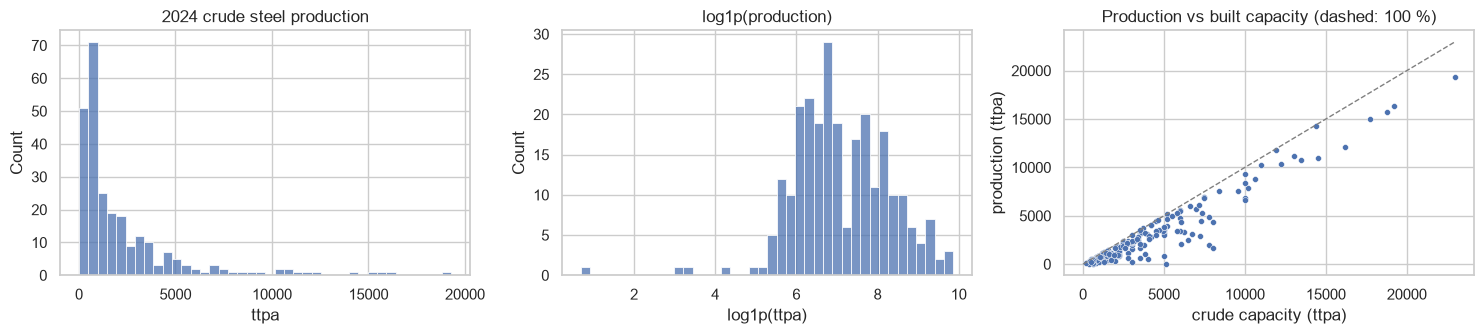

Cleaned table (257, 21) passes the schema.


In [3]:
def parse_number(column: str) -> pl.Expr:
    """Text -> Float64. 'unknown', 'N/A' and '>0' carry no value and become null."""
    return pl.col(column).cast(pl.Float64, strict=False).alias(column)


def has_unit(column: str) -> pl.Expr:
    """Upstream unit present? 'N/A' (not applicable) -> 0, a number or '>x' -> 1, 'unknown' -> null."""
    raw = pl.col(column)
    return pl.when(raw == "N/A").then(0.0).when(raw == "unknown").then(None).otherwise(1.0)


def certification(column: str) -> pl.Expr:
    """A date, year, 'yes' or 'y' means certified; 'no' and 'expired' mean not; 'unknown' stays unknown."""
    raw = pl.col(column).str.to_lowercase()
    return (pl.when(raw == "unknown").then(pl.lit("unknown"))
            .when(raw.is_in(["no", "expired"])).then(pl.lit("no"))
            .otherwise(pl.lit("yes")).alias(column))


def clean(df: pl.DataFrame) -> pl.DataFrame:
    """Coerce raw text columns to the types the schema expects. Works with or without the target column."""
    out = df.with_columns(
        parse_number("plant_age"),
        parse_number("workforce_size"),
        has_unit("sinter_capacity").alias("has_sinter_plant"),
        has_unit("coking_capacity").alias("has_coking_plant"),
        has_unit("pelletizing_capacity").alias("has_pelletizing_plant"),
        certification("iso_14001"),
        certification("iso_50001"),
        certification("responsible_steel"),
    ).drop("sinter_capacity", "coking_capacity", "pelletizing_capacity")
    if TARGET in out.columns:
        out = out.with_columns(parse_number(TARGET))
    return out


# 1) Coerce: dtype failures are fixed by parsing the text columns
df_parsed = clean(df_raw)

# 2) Drop: duplicate plant ids (keep the row with a numeric target, if any) and plants without a label.
#    A missing target cannot be imputed without inventing the answer.
df_parsed = (df_parsed.sort(TARGET, nulls_last=True)
             .unique("plant_id", keep="first", maintain_order=True)
             .sort("plant_id"))
unlabelled = df_parsed[TARGET].is_null()
print(f"Dropping {unlabelled.sum()} plants without a numeric 2024 crude-steel figure; {(~unlabelled).sum()} remain.")
df_clean = df_parsed.filter(~unlabelled)

# 3) Relax: the plant_age <= 150 check was stricter than reality. These are genuine 19th-century works.
print("\nLabelled plants older than 150 years:")
display(df_clean.filter(pl.col("plant_age") > 150).select("plant_name", "country", "plant_age"))
schema = build_schema(df_raw, max_plant_age=300)

# 4) Outliers: extreme utilisation is real (idle or ramping plants) or an estimate (production == capacity); kept
utilisation = (pl.col(TARGET) / pl.col("crude_capacity")).alias("utilisation")
print("Lowest and highest utilisation (2024 production / built capacity):")
ranked = df_clean.select("plant_name", "country", "status", "crude_capacity", TARGET, utilisation).sort("utilisation")
display(pl.concat([ranked.head(4), ranked.tail(4)]))

NUMERIC_RAW = ["crude_capacity", "crude_capacity_operating", "eaf_capacity", "iron_capacity",
               "workforce_size", "plant_age", TARGET]


def iqr_outliers(s: pl.Series) -> int:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return int(((s < q1 - 1.5 * (q3 - q1)) | (s > q3 + 1.5 * (q3 - q1))).sum())


display(pl.DataFrame({
    "column": NUMERIC_RAW,
    "missing": [df_clean[c].null_count() for c in NUMERIC_RAW],
    "IQR outliers": [iqr_outliers(df_clean[c].drop_nulls()) for c in NUMERIC_RAW],
    "skew": [df_clean[c].skew() for c in NUMERIC_RAW],
    "skew after log1p": [df_clean[c].log1p().skew() for c in NUMERIC_RAW],
}))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
sns.histplot(df_clean[TARGET].to_numpy(), bins=40, ax=axes[0]).set(title="2024 crude steel production", xlabel="ttpa")
sns.histplot(np.log1p(df_clean[TARGET].to_numpy()), bins=40, ax=axes[1]).set(title="log1p(production)", xlabel="log1p(ttpa)")
sns.scatterplot(x=df_clean["crude_capacity"].to_numpy(), y=df_clean[TARGET].to_numpy(), s=18, ax=axes[2])
axes[2].plot([0, df_clean["crude_capacity"].max()], [0, df_clean["crude_capacity"].max()], "--", c="grey", lw=1)
axes[2].set(title="Production vs built capacity (dashed: 100 %)", xlabel="crude capacity (ttpa)", ylabel="production (ttpa)")
plt.tight_layout()
plt.show()

# 5) Re-validate with the (relaxed) schema
schema.validate(df_clean, lazy=True)
print(f"Cleaned table {df_clean.shape} passes the schema.")


> 📝 *Critical thinking:*
> Explain your cleaning choices. Why did you treat the missing or skewed data in that way?

- **Missing target:** rows were dropped rather than imputed, because imputing the label would invent the answer we are trying to learn.
- **Missing features:** `N/A` was mapped to 0 for "has this unit" flags, since the unit does not exist. `unknown` was left as null and is imputed by the median **inside the pipeline**, fitted on the training folds only, to avoid leakage. Certifications became yes/no/unknown categories.
- **Outliers:** extreme utilisation plants were kept, for example Sidor in Venezuela at 0.5 % or plants whose production equals capacity. They are real (idle or ramping plants) or tracker estimates, not typing errors.
- **Skew:** we added `log_crude_capacity` as a feature but kept the target in tonnes. Production is almost proportional to capacity on the raw scale (Pearson 0.97). Task 3.2 confirms the choice: Ridge on a log target has a worse CV RMSE (1028 vs 849).

### **Task 1.4 – Feature Engineering**
- Create at least two new variables that might improve model performance (e.g., “capacity per worker”, “energy efficiency”).
- Encode categorical variables and standardize numeric ones.
- Bonus: you are free to use external socioeconomic or environmental data sources to enhance your feature set.


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

EQUIPMENT = ["BF", "BOF", "EAF", "DRI"]


def add_features(df: pl.DataFrame) -> pl.DataFrame:
    """Row-wise features only (no statistics across rows), so they cannot leak test information."""
    equipment = pl.col("main_equipment").str.split(";").list.eval(pl.element().str.strip_chars())
    return df.with_columns(
        (pl.col("crude_capacity_operating") / pl.col("crude_capacity")).alias("operating_share"),
        (pl.col("eaf_capacity") / pl.col("crude_capacity")).clip(0, 1).alias("eaf_share"),
        (pl.col("iron_capacity") / pl.col("crude_capacity")).alias("iron_to_steel_ratio"),
        (pl.col("crude_capacity") / pl.col("workforce_size")).alias("capacity_per_worker"),
        pl.col("crude_capacity").log1p().alias("log_crude_capacity"),
        *[equipment.list.contains(unit).cast(pl.Int8).alias(f"uses_{unit.lower()}") for unit in EQUIPMENT],
    )


NUMERIC = ["crude_capacity", "log_crude_capacity", "operating_share", "eaf_share", "iron_to_steel_ratio",
           "workforce_size", "capacity_per_worker", "plant_age",
           "has_sinter_plant", "has_coking_plant", "has_pelletizing_plant",
           "uses_bf", "uses_bof", "uses_eaf", "uses_dri"]
CATEGORICAL = ["region", "country", "soe_status", "status", "product_category", "iso_14001", "responsible_steel"]
FEATURES = NUMERIC + CATEGORICAL

df_model = add_features(df_clean)
display(df_model.select("plant_name", "operating_share", "eaf_share", "iron_to_steel_ratio",
                        "capacity_per_worker", "log_crude_capacity", *[f"uses_{u.lower()}" for u in EQUIPMENT]).head(5))

train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=SEED)
X_train, X_test = train_df.select(FEATURES), test_df.select(FEATURES)
y_train, y_test = train_df[TARGET].to_numpy(), test_df[TARGET].to_numpy()
print(f"Train: {X_train.shape}, test: {X_test.shape}")


def make_preprocessor(numeric=NUMERIC, categorical=CATEGORICAL, drop=None) -> ColumnTransformer:
    """Impute + scale numerics, impute + one-hot categoricals. Always fitted inside a pipeline on training rows."""
    numeric_steps = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
    categorical_steps = Pipeline([
        ("impute", SimpleImputer(missing_values=None, strategy="constant", fill_value="unknown")),
        ("encode", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=5, drop=drop,
                                 sparse_output=False)),
    ])
    return ColumnTransformer([("num", numeric_steps, numeric), ("cat", categorical_steps, categorical)],
                             verbose_feature_names_out=False)


preview = make_preprocessor().set_output(transform="polars").fit(X_train)  # fitted on the training split only
X_train_encoded = preview.transform(X_train)
print(f"Encoded training matrix: {X_train_encoded.shape} "
      f"({len(NUMERIC)} scaled numerics + {X_train_encoded.width - len(NUMERIC)} one-hot columns)")
display(X_train_encoded.select(NUMERIC[:5]).describe().filter(pl.col("statistic").is_in(["mean", "std"])))


plant_name,operating_share,eaf_share,iron_to_steel_ratio,capacity_per_worker,log_crude_capacity,uses_bf,uses_bof,uses_eaf,uses_dri
str,f64,f64,f64,f64,f64,i8,i8,i8,i8
"""Emsteel Abu Dhabi steel plant""",1.000,1.000,1.200,0.945,8.161,0,0,1,1
"""ArcelorMittal Acindar Villa Constitución stee…",1.000,1.000,0.300,1.255,7.601,0,0,1,1
"""TenarisSiderca Campana steel plant""",0.764,1.000,0.427,0.752,7.719,0,0,1,1
"""Ternium Siderar San Nicolás steel plant""",1.000,0.000,1.147,1.688,8.161,1,1,0,0
"""Gerdau Sipar Pérez steel plant""",1.000,1.000,0.000,0.908,6.479,0,0,1,0


Train: (205, 22), test: (52, 22)
Encoded training matrix: (205, 49) (15 scaled numerics + 34 one-hot columns)


statistic,crude_capacity,log_crude_capacity,operating_share,eaf_share,iron_to_steel_ratio
str,f64,f64,f64,f64,f64
"""mean""",-0.000,0.000,-0.000,-0.000,0.000
"""std""",1.002,1.002,1.002,1.002,1.002


> 📝 *Critical thinking:*
> Document your new feature(s). What business or operational insight do they represent?

- `operating_share` = operating / built capacity: the share of the plant that is actually available (mothballed or retired units produce nothing).
- `eaf_share` = EAF / crude capacity: the steelmaking route (scrap-based electric vs integrated).
- `iron_to_steel_ratio`: how self-sufficient the plant is in iron, which separates integrated mills from scrap mills.
- `capacity_per_worker`: labour productivity or automation level.
- `log_crude_capacity`: dampens the scale effect.
- `uses_bf/bof/eaf/dri`: equipment flags.

Categoricals are one-hot encoded (rare levels grouped) and numerics are standardized, all fitted on the training split only.

## 🔍 1.5 Feature Relationships and Correlations

### 🧭 Objective
Before training models, it’s essential to understand how features relate to each other and to the target variable — both linearly and nonlinearly. This helps identify redundant or uninformative predictors and guides model choice.

---

### **Task 1.5.1 – Correlation Matrix (Linear Relationships)**
- Compute a **correlation matrix** (e.g., using `df.corr()`, `seaborn.heatmap`, `skrub`) to examine pairwise linear relationships among numerical features.
- Focus on correlations between each feature and the target (`production`), as well as between features themselves.


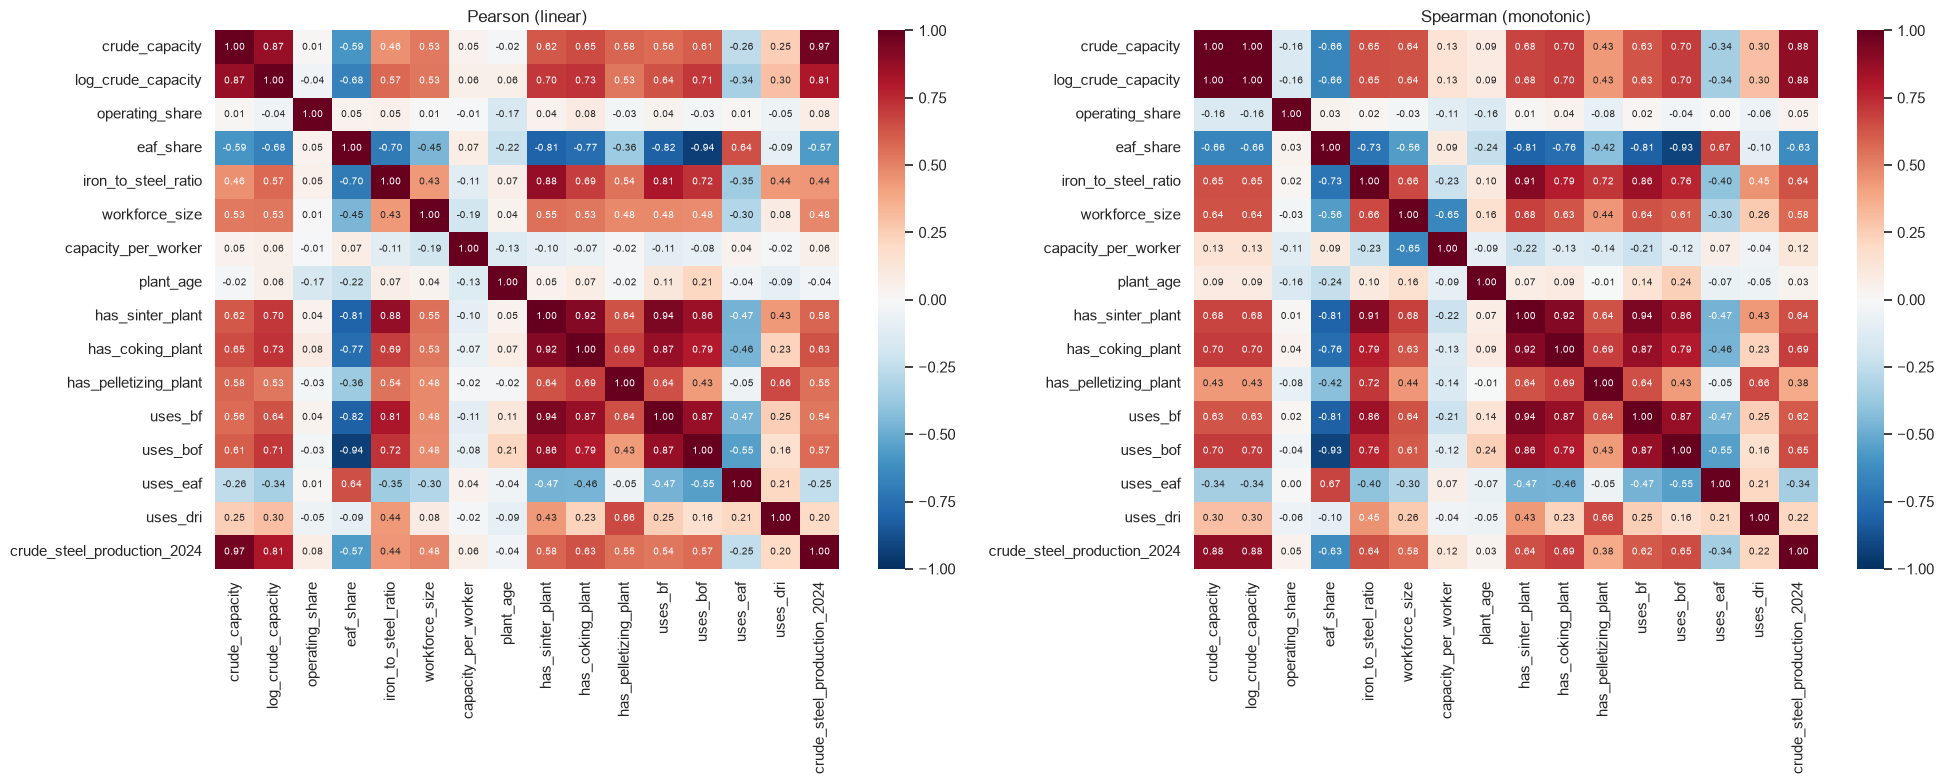

Correlation with the target:


feature,pearson,spearman
str,f64,f64
"""crude_capacity""",0.966,0.883
"""log_crude_capacity""",0.808,0.883
"""has_coking_plant""",0.635,0.693
"""has_sinter_plant""",0.580,0.643
"""uses_bof""",0.569,0.652
"""eaf_share""",-0.566,-0.626
"""has_pelletizing_plant""",0.548,0.380
"""uses_bf""",0.538,0.617
"""workforce_size""",0.485,0.577


Highly correlated feature pairs (|Pearson| > 0.8):


feature_a,feature_b,pearson
str,str,f64
"""crude_capacity""","""log_crude_capacity""",0.874
"""eaf_share""","""has_sinter_plant""",-0.808
"""eaf_share""","""uses_bf""",-0.817
"""eaf_share""","""uses_bof""",-0.939
"""iron_to_steel_ratio""","""has_sinter_plant""",0.882
"""iron_to_steel_ratio""","""uses_bf""",0.813
"""has_sinter_plant""","""has_coking_plant""",0.917
"""has_sinter_plant""","""uses_bf""",0.940
"""has_sinter_plant""","""uses_bof""",0.862


In [5]:
CORR_COLUMNS = NUMERIC + [TARGET]


def correlation_matrix(df: pl.DataFrame, columns: list[str], method: str) -> np.ndarray:
    """Pairwise-complete correlations, so a missing workforce value does not drop the whole row."""
    m = np.eye(len(columns))
    for i, a in enumerate(columns):
        for j in range(i + 1, len(columns)):
            b = columns[j]
            m[i, j] = m[j, i] = df.select(a, b).drop_nulls().select(pl.corr(a, b, method=method)).item()
    return m


pearson = correlation_matrix(train_df, CORR_COLUMNS, "pearson")    # training rows only
spearman = correlation_matrix(train_df, CORR_COLUMNS, "spearman")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, (title, m) in zip(axes, {"Pearson (linear)": pearson, "Spearman (monotonic)": spearman}.items()):
    sns.heatmap(m, xticklabels=CORR_COLUMNS, yticklabels=CORR_COLUMNS, cmap="RdBu_r", vmin=-1, vmax=1,
                annot=True, fmt=".2f", annot_kws={"size": 7}, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

print("Correlation with the target:")
display(pl.DataFrame({"feature": CORR_COLUMNS[:-1], "pearson": pearson[-1, :-1], "spearman": spearman[-1, :-1]})
        .sort(pl.col("pearson").abs(), descending=True))

print("Highly correlated feature pairs (|Pearson| > 0.8):")
pairs = [(CORR_COLUMNS[i], CORR_COLUMNS[j], pearson[i, j])
         for i in range(len(NUMERIC)) for j in range(i + 1, len(NUMERIC)) if abs(pearson[i, j]) > 0.8]
display(pl.DataFrame(pairs, schema=["feature_a", "feature_b", "pearson"], orient="row"))


> 📝 *Critical thinking:*
> Which variables show the strongest correlation with production?
> Do any features appear redundant or highly correlated with each other?

**Answer.** `crude_capacity` dominates, with Pearson 0.97 and Spearman 0.88 with production. Next come the upstream or integrated-route indicators (`has_coking_plant` 0.64, `has_sinter_plant`, `uses_bof`) and a negative `eaf_share` (−0.57): integrated mills are larger. `operating_share`, `capacity_per_worker` and `plant_age` are close to 0 linearly.

Redundancy is strong. `uses_bf`, `uses_bof`, `has_sinter_plant`, `has_coking_plant` and `eaf_share` are all |r| > 0.8 with each other, because they describe the same BF-BOF route. `crude_capacity` and its log are also 0.87 correlated. This motivates regularisation (Ridge) or a smaller key-variable set.

## 🧮 2. Building Baseline & Linear Models

### 🧭 Objective
Establish a simple baseline, then train and interpret a linear model.

---

### **Task 2.1 – Baseline**
- Compute a simple baseline predictor (mean or median production) with `sklearn.dummy.DummyRegressor`. Report RMSE and MAE on the held-out test set.
- Build a second baseline as a pipeline, using **one** of the following. Fit preprocessing on the training split only (inside the pipeline, not on the full table):
  - **scikit-learn:** a `Pipeline` with preprocessing (`ColumnTransformer`: impute, encode categoricals, scale numerics) and a default regressor.
  - **skrub:** [`tabular_pipeline("regressor")`](https://skrub-data.org/stable/reference/generated/skrub.tabular_pipeline.html), which wires a `TableVectorizer` to an estimator-appropriate preprocessor.
- Compare the pipeline’s RMSE and MAE with the dummy baseline.


In [6]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error


def scores(model, X, y) -> dict[str, float]:
    pred = model.predict(X)
    return {"RMSE": root_mean_squared_error(y, pred), "MAE": mean_absolute_error(y, pred), "R2": r2_score(y, pred)}


dummy = DummyRegressor(strategy="median").fit(X_train, y_train)
baseline_pipeline = Pipeline([
    ("preprocess", make_preprocessor()),
    ("model", HistGradientBoostingRegressor(random_state=SEED)),
]).fit(X_train, y_train)

display(pl.DataFrame([
    {"model": "DummyRegressor (median)", **scores(dummy, X_test, y_test)},
    {"model": "Pipeline: ColumnTransformer + HistGradientBoosting", **scores(baseline_pipeline, X_test, y_test)},
]))


model,RMSE,MAE,R2
str,f64,f64,f64
"""DummyRegressor (median)""",3036.697,1645.827,-0.194
"""Pipeline: ColumnTransformer + HistGradientBoo…",1262.353,652.999,0.794


> 📝 *Critical thinking:*
> Why is it useful to have a baseline model before trying more complex ones?
> Did your pipeline beat the dummy baseline? If the gap is small, what does that say about the features?

**Answer.** A baseline tells us whether a model learns anything at all, and it sets the bar that more complex models must beat. The median dummy scores RMSE ≈ 3,037 and R² −0.19. The HistGradientBoosting pipeline scores RMSE ≈ 1,262 and R² 0.79, so it clearly wins because capacity carries most of the signal. It still falls well behind the linear models (next tasks). With only 205 training rows, trees cannot extrapolate to the few very large plants.

### **Task 2.2 – Linear Regression**
- Train a multiple linear regression model using the key plant variables.
- Display coefficients and interpret their meaning.
- Evaluate the model on training and test data.


In [7]:
from sklearn.linear_model import LinearRegression

KEY_NUMERIC = ["crude_capacity", "operating_share", "eaf_share", "iron_to_steel_ratio", "workforce_size", "plant_age"]
KEY_CATEGORICAL = ["region", "soe_status"]

linear_key = Pipeline([
    ("preprocess", make_preprocessor(KEY_NUMERIC, KEY_CATEGORICAL, drop="first")),  # drop="first": identifiable dummies
    ("model", LinearRegression()),
]).fit(X_train, y_train)

scaler = linear_key["preprocess"].named_transformers_["num"]["scale"]
one_sd = dict(zip(KEY_NUMERIC, scaler.scale_))
coefficients = (
    pl.DataFrame({"feature": linear_key["preprocess"].get_feature_names_out(), "coefficient": linear_key["model"].coef_})
    .with_columns(pl.col("feature").replace_strict(one_sd, default=None).alias("1 SD in original units"))
    .sort(pl.col("coefficient").abs(), descending=True)
)
print(f"Intercept: {linear_key['model'].intercept_:.0f} ttpa. Numeric coefficients are ttpa per +1 SD; "
      f"categorical ones are relative to the dropped first level.")
display(coefficients)
display(pl.DataFrame([{"split": "train", **scores(linear_key, X_train, y_train)},
                      {"split": "test", **scores(linear_key, X_test, y_test)}]))


Intercept: 1279 ttpa. Numeric coefficients are ttpa per +1 SD; categorical ones are relative to the dropped first level.


feature,coefficient,1 SD in original units
str,f64,f64
"""crude_capacity""",3017.568,3730.610
"""soe_status_Partial""",1250.319,null
"""soe_status_N/A""",1162.829,null
"""region_Eurasia""",-325.627,null
"""region_North America""",-190.148,null
"""operating_share""",153.273,0.193
"""region_Central & South America""",-88.072,null
"""region_infrequent_sklearn""",56.034,null
"""workforce_size""",-50.574,4400.903


split,RMSE,MAE,R2
str,f64,f64,f64
"""train""",749.161,485.364,0.942
"""test""",898.783,509.989,0.895


> 📝 *Critical thinking:*
> Interpret one positive and one negative coefficient. What do they tell you about plant performance drivers?

**Answer.**
- **Positive:** `crude_capacity` has +3,018 ttpa per +1 SD (3,731 ttpa of capacity). That is about 0.81 t produced per tonne of capacity, i.e. typical utilisation around 80 %. Capacity is the first-order driver.
- **Negative:** `region_Eurasia` has −326 ttpa relative to Africa, the reference level. At equal capacity, Russian and Ukrainian plants produced less in 2024, consistent with war and sanctions lowering utilisation.

`soe_status` Partial/N/A are +1.2 Mt relative to fully state-owned plants, which suggests lower utilisation at fully state-owned plants in this sample. With few such plants, this should be read cautiously. Test R² is 0.895 vs 0.942 on train, a mild gap.

## 🔁 3. Model Evaluation and Selection

### 🧭 Objective
Use cross-validation to estimate generalization performance and compare multiple model types.

---

### **Task 3.1 – Cross-Validation**
- Apply **K-Fold cross-validation** (e.g., K=5).
- Record the average RMSE, MAE, and R² across folds.


In [8]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"RMSE": "neg_root_mean_squared_error", "MAE": "neg_mean_absolute_error", "R2": "r2"}


def cross_val(model) -> pl.DataFrame:
    """Per-fold scores on the training split; the test split stays untouched."""
    r = cross_validate(model, X_train, y_train, cv=cv, scoring=SCORING)
    return pl.DataFrame({"fold": np.arange(1, cv.n_splits + 1),
                         "RMSE": -r["test_RMSE"], "MAE": -r["test_MAE"], "R2": r["test_R2"]})


def mean_std(folds: pl.DataFrame) -> pl.DataFrame:
    return pl.concat([folds.drop("fold").mean().insert_column(0, pl.Series("stat", ["mean"])),
                      folds.drop("fold").std().insert_column(0, pl.Series("stat", ["std"]))])


linear_folds = cross_val(linear_key)
display(linear_folds)
display(mean_std(linear_folds))


fold,RMSE,MAE,R2
i64,f64,f64,f64
1,661.500,478.652,0.956
2,948.134,601.743,0.934
3,1086.383,645.476,0.876
4,849.229,554.505,0.852
5,653.374,442.445,0.958


stat,RMSE,MAE,R2
str,f64,f64,f64
"""mean""",839.724,544.564,0.915
"""std""",186.530,84.149,0.048


> 📝 *Critical thinking:*
> Summarize your results. How stable is performance across folds? What might this indicate about model variance?

**Answer.** Five-fold CV of the key-variable linear model gives RMSE 840 ± 187, MAE 545 ± 84 and R² 0.915 ± 0.048. Fold RMSE ranges from 653 to 1,086. The variation comes mainly from which of the few very large plants land in a fold, since RMSE is dominated by them. The model has moderate variance: with 257 plants, any single split is noisy, which is why we select models on CV rather than on one test split.

### **Task 3.2 – Model Comparison**
Train and compare at least **three models**, on the same folds and metrics as Task 3.1:
- Linear Regression
- Ridge Regression (regularized linear)
- Random Forest Regressor

Record cross-validation performance for each model.

**Bonus — tabular foundation model:** add [TabFM](https://github.com/google-research/tabfm) v1.0 (Google Research). Install the PyTorch extra from that repo, then:

```python
from tabfm import TabFMRegressor
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0

reg = TabFMRegressor(model=tabfm_v1_0_0.load(model_type="regression"))
```

`fit` stores the training rows as context; `predict` is one forward pass, with no hyperparameter search. The default context is 100 rows (`max_num_rows`). A single held-out split is enough. Pretrained weights are non-commercial and not for production. In the results table, say whether it beats your best classical model, and which model you would actually deploy. Python 3.11 or newer is required.


In [9]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge


def pipeline(model) -> Pipeline:
    return Pipeline([("preprocess", make_preprocessor()), ("model", model)])


candidates = {
    "Linear Regression": pipeline(LinearRegression()),
    "Ridge": pipeline(Ridge()),
    "Random Forest": pipeline(RandomForestRegressor(random_state=SEED, n_jobs=-1)),
    # checks the Task 1.3 decision to keep the target on its original scale
    "Ridge, log target": pipeline(TransformedTargetRegressor(Ridge(), func=np.log1p, inverse_func=np.expm1)),
}

rows, fold_scores = [], {}
for name, model in candidates.items():
    folds = fold_scores[name] = cross_val(model)
    model.fit(X_train, y_train)
    rows.append({"model": name,
                 "cv_RMSE": folds["RMSE"].mean(), "cv_RMSE_std": folds["RMSE"].std(),
                 "cv_MAE": folds["MAE"].mean(), "cv_R2": folds["R2"].mean(),
                 **{f"test_{k}": v for k, v in scores(model, X_test, y_test).items()}})
comparison = pl.DataFrame(rows).sort("cv_RMSE")
display(comparison)


model,cv_RMSE,cv_RMSE_std,cv_MAE,cv_R2,test_RMSE,test_MAE,test_R2
str,f64,f64,f64,f64,f64,f64,f64
"""Ridge""",848.663,196.315,595.761,0.915,917.602,592.896,0.891
"""Linear Regression""",877.833,170.313,625.900,0.908,918.444,616.128,0.891
"""Random Forest""",917.109,239.571,549.552,0.907,813.009,445.918,0.914
"""Ridge, log target""",1027.990,208.656,618.346,0.882,908.390,482.675,0.893


> 📝 *Critical thinking:*
> Create a small results table. Which model performs best? Why might that be the case given the dataset’s characteristics?

See the table above (same 5 folds).
- **Ridge** has the best CV RMSE (849), followed by Linear (878) and Random Forest (917). The Random Forest has the best CV MAE (550) and the best test scores (RMSE 813), but also the highest fold variance.
- **Why:** the relationship is nearly linear in capacity. Linear models extrapolate well to the largest plants, which dominate RMSE. Ridge helps against the collinear route features. The forest handles the typical plant better (lower MAE) but cannot predict beyond the largest training values.
- **Differences:** all gaps (about 30–70 ttpa) are small relative to the fold standard deviation (about 200).

*The TabFM bonus was not attempted (6.6 GB of weights).*

### **Task 3.3 – Hyperparameter Optimization**
- Use **RandomizedSearchCV** or **GridSearchCV** to tune the top model (e.g., Random Forest).
- Report the best parameters and corresponding validation score.


In [10]:
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV

# Ridge had the best cross-validated RMSE in Task 3.2, so it is the model we tune here.
# The search covers the whole pipeline: regularisation strength and two preprocessing choices.
search = RandomizedSearchCV(
    pipeline(Ridge()),
    param_distributions={
        "model__alpha": loguniform(1e-2, 1e3),
        "preprocess__cat__encode__min_frequency": [1, 3, 5, 10, 20],
        "preprocess__num__impute__strategy": ["mean", "median"],
    },
    n_iter=40, cv=cv, scoring=SCORING, refit="RMSE", random_state=SEED, n_jobs=-1,
)
search.fit(X_train, y_train)

ridge_default_cv = comparison.filter(pl.col("model") == "Ridge")["cv_RMSE"].item()
ridge_tuned_folds = cross_val(search.best_estimator_)
print("Best parameters:", {k: round(float(v), 3) if isinstance(v, float) else v for k, v in search.best_params_.items()})
print(f"Ridge CV RMSE: default {ridge_default_cv:.1f} -> tuned {-search.best_score_:.1f} ttpa")

top5 = (pl.DataFrame({
    "alpha": search.cv_results_["param_model__alpha"].astype(float),
    "min_frequency": search.cv_results_["param_preprocess__cat__encode__min_frequency"].astype(int),
    "impute": search.cv_results_["param_preprocess__num__impute__strategy"].astype(str),
    "cv_RMSE": -search.cv_results_["mean_test_RMSE"],
    "cv_R2": search.cv_results_["mean_test_R2"],
}).sort("cv_RMSE").head(5))
display(top5)
display(pl.DataFrame([{"model": "Ridge, tuned", **scores(search.best_estimator_, X_test, y_test)}]))


Best parameters: {'model__alpha': 3.725, 'preprocess__cat__encode__min_frequency': 1, 'preprocess__num__impute__strategy': 'mean'}
Ridge CV RMSE: default 848.7 -> tuned 844.6 ttpa


alpha,min_frequency,impute,cv_RMSE,cv_R2
f64,i64,str,f64,f64
3.725,1,"""mean""",844.577,0.918
1.773,3,"""median""",848.107,0.916
2.297,20,"""mean""",849.189,0.915
0.620,1,"""median""",852.302,0.915
4.206,3,"""median""",852.904,0.917


model,RMSE,MAE,R2
str,f64,f64,f64
"""Ridge, tuned""",925.616,546.291,0.889


> 📝 *Critical thinking:*
> Discuss the role of hyperparameter tuning. How did tuning change your model’s performance compared to default settings?

Tuning searches for the hyperparameters that generalise best, measured on the CV folds, never on the test set. For Ridge, RandomizedSearchCV (40 draws over alpha, the rare-category threshold and the imputer) improved CV RMSE only from 849 to 845. Ridge's defaults were already near optimal, and the remaining error is noise in the data (unobserved utilisation shocks), not model capacity. The tuned test RMSE (926) is even slightly worse than the default's (918), a reminder that small CV gains do not always carry over to a 52-plant test set.

## ⚙️ 4. Model Lifecycle: Tracking, Saving, and Loading

### 🧭 Objective
Apply tools that support reproducible ML experiments.

---

### **Task 4.1 – Experiment Tracking with MLflow**
- Use MLflow to log parameters (model type, hyperparameters), metrics (RMSE, R²), and artifacts (a plot, the feature list, or your Pandera schema).
- Run and record at least two experiments (for example the Task 2.1 baseline and your best model).


In [11]:
import json

import mlflow

MLFLOW_URI = "sqlite:///mlflow.db"
EXPERIMENT = "gist-crude-steel-2024"
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT)

schema_spec = {name: {"dtype": str(col.dtype), "nullable": col.nullable, "unique": col.unique,
                      "checks": [str(check) for check in col.checks]}
               for name, col in schema.columns.items()}


def prediction_plot(predictions: np.ndarray, title: str):
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.scatter(y_test, predictions, s=16)
    upper = max(y_test.max(), predictions.max()) * 1.05
    ax.plot([0, upper], [0, upper], "--", c="grey", lw=1)
    ax.set(xlabel="actual 2024 production (ttpa)", ylabel="predicted (ttpa)", title=title)
    return fig


def log_experiment(name: str, model, folds: pl.DataFrame | None = None) -> str:
    estimator = model["model"] if isinstance(model, Pipeline) else model
    params = {k: v for k, v in estimator.get_params().items() if isinstance(v, (int, float, str, bool, type(None)))}
    predictions = model.predict(X_test)
    with mlflow.start_run(run_name=name) as run:
        mlflow.log_params({"model_type": type(estimator).__name__, "target": TARGET,
                           "n_train": len(y_train), "n_test": len(y_test), **params})
        mlflow.log_metrics({"test_RMSE": root_mean_squared_error(y_test, predictions),
                            "test_MAE": mean_absolute_error(y_test, predictions),
                            "test_R2": r2_score(y_test, predictions)})
        if folds is not None:
            mlflow.log_metrics({f"cv_{m}": folds[m].mean() for m in ("RMSE", "MAE", "R2")})
        mlflow.log_dict({"numeric": NUMERIC, "categorical": CATEGORICAL, "target": TARGET}, "features.json")
        mlflow.log_dict(schema_spec, "pandera_schema.json")
        fig = prediction_plot(predictions, name)
        mlflow.log_figure(fig, "pred_vs_actual.png")
        plt.close(fig)
    return run.info.run_id


experiments = {
    "dummy-median": (dummy, cross_val(DummyRegressor(strategy="median"))),
    "hgb-pipeline-baseline": (baseline_pipeline, cross_val(baseline_pipeline)),
    "linear-key-variables": (linear_key, linear_folds),
    "linear-all-features": (candidates["Linear Regression"], fold_scores["Linear Regression"]),
    "ridge": (candidates["Ridge"], fold_scores["Ridge"]),
    "random-forest": (candidates["Random Forest"], fold_scores["Random Forest"]),
    "ridge-log-target": (candidates["Ridge, log target"], fold_scores["Ridge, log target"]),
    "ridge-tuned-randomsearch": (search.best_estimator_, ridge_tuned_folds),
}
run_ids = {name: log_experiment(name, model, folds) for name, (model, folds) in experiments.items()}

logged = [mlflow.get_run(run_id) for run_id in run_ids.values()]
display(pl.DataFrame([{"run": r.info.run_name, "run_id": r.info.run_id[:8],
                       **{m: r.data.metrics.get(m) for m in ("cv_RMSE", "cv_R2", "test_RMSE", "test_MAE", "test_R2")}}
                      for r in logged]).sort("cv_RMSE", nulls_last=True))
print(f"{len(logged)} runs logged to {MLFLOW_URI}, experiment '{EXPERIMENT}'. "
      f"Browse them with: uv run mlflow ui --backend-store-uri {MLFLOW_URI}")


/Users/jawadmallat/Desktop/AIDAMS_3A/research_course/Lab2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026/09/25 11:37:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/25 11:37:37 INFO mlflow.store.db.utils: Updating database tables


2026/09/25 11:37:37 INFO mlflow.tracking.fluent: Experiment with name 'gist-crude-steel-2024' does not exist. Creating a new experiment.


run,run_id,cv_RMSE,cv_R2,test_RMSE,test_MAE,test_R2
str,str,f64,f64,f64,f64,f64
"""linear-key-variables""","""6cc0ff64""",839.724,0.915,898.783,509.989,0.895
"""ridge-tuned-randomsearch""","""73d80b85""",844.577,0.918,925.616,546.291,0.889
"""ridge""","""440859c9""",848.663,0.915,917.602,592.896,0.891
"""linear-all-features""","""db4bd791""",877.833,0.908,918.444,616.128,0.891
"""random-forest""","""74f34883""",917.109,0.907,813.009,445.918,0.914
"""ridge-log-target""","""454f469b""",1027.990,0.882,908.390,482.675,0.893
"""hgb-pipeline-baseline""","""985c81ec""",1743.879,0.661,1262.353,652.999,0.794
"""dummy-median""","""2ade1a8f""",3345.754,-0.187,3036.697,1645.827,-0.194


8 runs logged to sqlite:///mlflow.db, experiment 'gist-crude-steel-2024'. Browse them with: uv run mlflow ui --backend-store-uri sqlite:///mlflow.db


> 📝 *Critical thinking:*
> Describe how MLflow helps manage your experiments. What advantages does it give compared to manual tracking?

 Each run stores its parameters, CV and test metrics, the feature list, the Pandera schema (JSON) and a predicted-vs-actual plot in one SQLite store (`mlflow.db`). Runs can be sorted, compared and reproduced in the UI (`uv run mlflow ui --backend-store-uri sqlite:///mlflow.db`). Compared with manual tracking in notebooks or spreadsheets, nothing gets lost or mis-copied, every metric is tied to the exact configuration and artifacts that produced it, and teammates see the same history.

### **Task 4.2 – Hyperparameter Optimization with Optuna**
- Define an Optuna study to optimize one classical model (Ridge or Random Forest). Skip TabFM here.
- Use a fixed budget (about 30 trials) and the same cross-validation metric as Task 3.
- Record the number of trials, the best parameters, and the score next to the untuned score from Task 3.2.
- Send the trials to the same store as Task 4.1 with `optuna.integration.MLflowCallback`.


/var/folders/pn/79lskznn0nj68mkf5kq8bsyr0000gn/T/ipykernel_48677/2584142170.py:25: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  callbacks=[MLflowCallback(tracking_uri=MLFLOW_URI, metric_name="cv_RMSE")])


2026/09/25 11:37:38 INFO mlflow.tracking.fluent: Experiment with name 'optuna-random-forest' does not exist. Creating a new experiment.


Trials: 30, best trial #17: {'n_estimators': 150, 'max_depth': 18, 'min_samples_leaf': 1, 'max_features': 0.693}


model,cv_RMSE
str,f64
"""Random Forest, default (Task 3.2)""",917.109
"""Random Forest, Optuna TPE (30 trials)""",891.467
"""Ridge, RandomizedSearchCV (Task 3.3)""",844.577


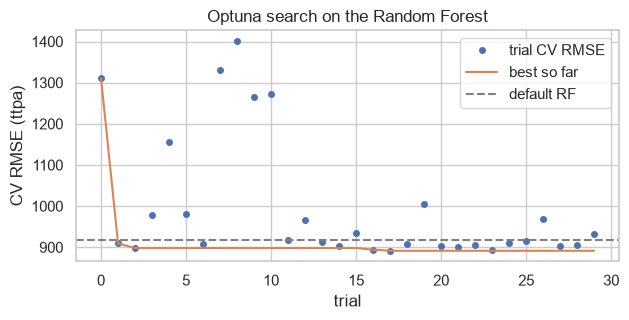

model,RMSE,MAE,R2
str,f64,f64,f64
"""Random Forest, Optuna""",865.726,465.739,0.903


In [12]:
import optuna
from optuna.integration import MLflowCallback

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)  # MLflowCallback is "experimental"

N_TRIALS = 30


def rf_objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 25),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_float("max_features", 0.2, 1.0),
    }
    model = pipeline(RandomForestRegressor(**params, random_state=SEED, n_jobs=-1))
    return cross_val(model)["RMSE"].mean()  # same folds and metric as Task 3


study = optuna.create_study(study_name="optuna-random-forest", direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
# Same MLflow store as Task 4.1; the callback files the trials under an experiment named after the study
study.optimize(rf_objective, n_trials=N_TRIALS,
               callbacks=[MLflowCallback(tracking_uri=MLFLOW_URI, metric_name="cv_RMSE")])
mlflow.set_experiment(EXPERIMENT)  # the callback switched the active experiment; switch back

rf_default_cv = comparison.filter(pl.col("model") == "Random Forest")["cv_RMSE"].item()
print(f"Trials: {len(study.trials)}, best trial #{study.best_trial.number}:",
      {k: round(v, 3) if isinstance(v, float) else v for k, v in study.best_params.items()})
display(pl.DataFrame({
    "model": ["Random Forest, default (Task 3.2)", f"Random Forest, Optuna TPE ({N_TRIALS} trials)",
              "Ridge, RandomizedSearchCV (Task 3.3)"],
    "cv_RMSE": [rf_default_cv, study.best_value, -search.best_score_],
}))

trial_values = np.array([t.value for t in study.trials])
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(trial_values, "o", ms=4, label="trial CV RMSE")
ax.plot(np.minimum.accumulate(trial_values), label="best so far")
ax.axhline(rf_default_cv, ls="--", c="grey", label="default RF")
ax.set(xlabel="trial", ylabel="CV RMSE (ttpa)", title="Optuna search on the Random Forest")
ax.legend()
plt.show()

rf_optuna = pipeline(RandomForestRegressor(**study.best_params, random_state=SEED, n_jobs=-1)).fit(X_train, y_train)
display(pl.DataFrame([{"model": "Random Forest, Optuna", **scores(rf_optuna, X_test, y_test)}]))


> 📝 *Critical thinking:*
> Explain what Optuna is doing behind the scenes. How is it different from Grid or Random Search?

**Answer.** Optuna uses a TPE sampler (Tree-structured Parzen Estimator). After a few random trials, it models the density of good and bad hyperparameters separately and proposes points where the ratio good/bad is highest. Each trial is informed by earlier ones, whereas grid and random search sample blindly: grid search is exhaustive but explodes combinatorially, and random search is independent draws.

Here, 30 trials cut the Random Forest's CV RMSE from 917 (default) to 891, but it still did not beat Ridge (845). The trials are logged in MLflow experiment `optuna-random-forest`. Note: `MLflowCallback` is deprecated since Optuna 4.9 but still works.

### **Task 4.3 – Model Storage**
- Save the best **pipeline** (preprocessing and model together), with `joblib` or `mlflow.sklearn.log_model`. Saving the estimator alone drops the encoder and imputer.
- Load the saved pipeline and re-evaluate it on the test set. The score should match the in-memory pipeline.


In [13]:
from pathlib import Path

import joblib
import sklearn

# Select on cross-validation only (same 5 folds for every model); the test split stays a final check.
finalists = {
    "Linear Regression, key variables (2.2)": (linear_key, linear_folds["RMSE"].mean()),
    **{f"{name} (3.2)": (model, fold_scores[name]["RMSE"].mean()) for name, model in candidates.items()},
    "Ridge, RandomizedSearchCV (3.3)": (search.best_estimator_, -search.best_score_),
    "Random Forest, Optuna (4.2)": (rf_optuna, study.best_value),
}
display(pl.DataFrame({"pipeline": list(finalists), "cv_RMSE": [cv for _, cv in finalists.values()]}).sort("cv_RMSE"))
best_name, (best_pipeline, best_cv_rmse) = min(finalists.items(), key=lambda item: item[1][1])
print(f"Best pipeline by CV RMSE: {best_name} ({best_cv_rmse:.1f} ttpa)")

MODEL_PATH = Path("models/best_pipeline.joblib")
MODEL_PATH.parent.mkdir(exist_ok=True)
joblib.dump(best_pipeline, MODEL_PATH)  # the whole Pipeline: imputers, encoder, scaler and model
loaded_pipeline = joblib.load(MODEL_PATH)

in_memory, reloaded = best_pipeline.predict(X_test), loaded_pipeline.predict(X_test)
print(f"Saved {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1024:.0f} KB). "
      f"Identical test predictions after reload: {np.array_equal(in_memory, reloaded)}")
display(pl.DataFrame([{"pipeline": "in memory", **scores(best_pipeline, X_test, y_test)},
                      {"pipeline": "loaded from disk", **scores(loaded_pipeline, X_test, y_test)}]))

with mlflow.start_run(run_name="best-pipeline"):
    mlflow.log_params({"selected_model": best_name, "sklearn_version": sklearn.__version__})
    mlflow.log_metrics({"cv_RMSE": best_cv_rmse, **{f"test_{k}": v for k, v in scores(loaded_pipeline, X_test, y_test).items()}})
    mlflow.log_artifact(str(MODEL_PATH))
    mlflow.log_dict(schema_spec, "pandera_schema.json")


pipeline,cv_RMSE
str,f64
"""Linear Regression, key variables (2.2)""",839.724
"""Ridge, RandomizedSearchCV (3.3)""",844.577
"""Ridge (3.2)""",848.663
"""Linear Regression (3.2)""",877.833
"""Random Forest, Optuna (4.2)""",891.467
"""Random Forest (3.2)""",917.109
"""Ridge, log target (3.2)""",1027.990


Best pipeline by CV RMSE: Linear Regression, key variables (2.2) (839.7 ttpa)
Saved models/best_pipeline.joblib (6 KB). Identical test predictions after reload: True


pipeline,RMSE,MAE,R2
str,f64,f64,f64
"""in memory""",898.783,509.989,0.895
"""loaded from disk""",898.783,509.989,0.895


> 📝 *Critical thinking:*
> Why is it important to store both model parameters and metadata? How would you ensure version control of models in a production setting?

**Answer.** The selected pipeline is the **8-variable linear model** (CV RMSE 840, the lowest, although statistically tied with Ridge). It was saved with joblib, and the reloaded copy gives identical predictions (test RMSE 899, R² 0.895).

The weights alone are not enough. You also need the preprocessing, the feature list, the schema, the library versions (a joblib file only loads reliably with the same scikit-learn version), the training data version and the metrics, to reproduce, audit or roll back a model. In production we would register each model in the MLflow Model Registry with a version and stage, pin the environment (`uv.lock`), version the data snapshot (for example the GIST release date), and promote models only through CI checks.

## 🚀 5. Deployment & Monitoring (Conceptual)

### 🧭 Objective
Reflect on how models transition from training to production and stay reliable over time.

---

### **Task 5.1 – Deployment Planning**

> 📝 *Critical thinking:*
> Describe how you would deploy the **saved pipeline** from Task 4.3 (REST API or batch job). Incoming rows should pass your Pandera schema before `predict`, so serving applies the same columns and checks as training.
> Which metrics would you monitor: error once actual production arrives, and the share of rows rejected by the schema?
> If you tried TabFM, would you deploy it or the classical pipeline? The pretrained weights are non-commercial and not for production use.

**Answer.** We would run a **batch job** each time GEM publishes a new GIST release, since the data is released periodically and does not need real-time serving. Optionally, a small FastAPI endpoint would serve the same function. Every row goes through `clean`, then the Pandera `serving_schema`, then `add_features` and `pipeline.predict` (see the demo below: the corrupted row is rejected, the others are scored).

Metrics to monitor:
- **Rejection rate** of the schema; an alert if it spikes.
- **Input drift** per feature.
- **RMSE and MAE** once actual production figures arrive the following year, compared with the validation RMSE of about 840.

In [14]:
serving_schema = schema.remove_columns([TARGET])  # incoming rows have no label yet


def predict_validated(raw_rows: pl.DataFrame, model=loaded_pipeline) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Serving path: the training-time cleaning, the Pandera contract, then the saved pipeline."""
    rows = clean(raw_rows).with_row_index("row")
    try:
        serving_schema.validate(rows, lazy=True)
        failures = pl.DataFrame(schema={"index": pl.Int64, "column": pl.String, "check": pl.String,
                                        "failure_case": pl.String})
    except pa.errors.SchemaErrors as err:
        failures = err.failure_cases
        if failures["index"].null_count():  # a wrong dtype or missing column: the whole batch is unusable
            raise
    bad_rows = failures["index"].cast(pl.UInt32).unique().implode()
    accepted = rows.filter(~pl.col("row").is_in(bad_rows))
    rejected = (rows.filter(pl.col("row").is_in(bad_rows)).select("row", "plant_id")
                .join(failures.select(pl.col("index").cast(pl.UInt32).alias("row"), "column", "check", "failure_case"),
                      on="row"))
    predictions = accepted.select("plant_id", "plant_name").with_columns(
        pl.Series("predicted_production_2024", model.predict(add_features(accepted).select(FEATURES))))
    return predictions, rejected


# A batch in the raw GIST format: four unseen plants from the test split plus one corrupted record
incoming = df_raw.filter(pl.col("plant_id").is_in(test_df["plant_id"].head(4).implode())).drop(TARGET)
corrupted = incoming.head(1).with_columns(pl.lit("P999999999999").alias("plant_id"),
                                          pl.lit("Atlantis").alias("region"),
                                          pl.lit(-500.0).alias("crude_capacity"))
predictions, rejected = predict_validated(pl.concat([incoming, corrupted]))
display(predictions)
print(f"Rejected by the schema: {rejected['row'].n_unique()} of {incoming.height + 1} rows")
display(rejected)


plant_id,plant_name,predicted_production_2024
str,str,f64
"""P100000120906""","""ArcelorMittal Kryvyi Rih steel plant""",5320.715
"""P100000120792""","""Ferrostal Labedy Gliwice steel plant""",256.302
"""P100000120518""","""JSW Steel Salem steel plant""",972.691
"""P100000120052""","""Simec Cariacica steel plant""",237.194


Rejected by the schema: 1 of 5 rows


row,plant_id,column,check,failure_case
u32,str,str,str,str
4,"""P999999999999""","""region""","""isin(['Africa', 'Asia Pacific', 'Central & So…","""Atlantis"""
4,"""P999999999999""","""crude_capacity""","""greater_than(0)""","""-500.0"""


### **Task 5.2 – Detecting Model Drift**

> 📝 *Critical thinking:*
> What signs might indicate your model needs retraining?
> Give one example of **data drift** and one of **concept drift** relevant to steel plant production.
> Name one column from your Pandera schema you would watch first, and what shift in that column would count as data drift.

**Answer.**
- **Retraining signals:** rising error once real production is published, drift alerts on inputs, a rising schema-rejection rate, or a new GIST release with renamed columns or new categories.
- **Data drift:** a wave of new small EAF mini-mills (as in the simulated batch 2) shifts `crude_capacity` down and `eaf_share` up. The KS test flags both.
- **Concept drift:** a demand collapse or new tariffs lower utilisation everywhere. The capacity → production relationship itself changes (0.8 t/t becomes 0.6 t/t) while the inputs look unchanged.
- **Column to watch first:** `crude_capacity`, the dominant feature. A significant shift in its distribution (KS p < 0.01, or the median moving by more than 25 %) would count as data drift.

In [15]:
from scipy.stats import ks_2samp

MONITORED = ["crude_capacity", "eaf_share", "operating_share", "workforce_size"]


def drift_report(reference: pl.DataFrame, current: pl.DataFrame, alpha: float = 0.01) -> pl.DataFrame:
    """Two-sample Kolmogorov-Smirnov test per feature: a small p-value means the distribution moved."""
    rows = []
    for column in MONITORED:
        ref, cur = reference[column].drop_nulls().to_numpy(), current[column].drop_nulls().to_numpy()
        result = ks_2samp(ref, cur)
        rows.append({"feature": column, "train_median": np.median(ref), "batch_median": np.median(cur),
                     "ks_stat": result.statistic, "p_value": result.pvalue, "drift": bool(result.pvalue < alpha)})
    return pl.DataFrame(rows)


print("Batch 1: the held-out test plants (same population as training, no drift expected)")
display(drift_report(X_train, X_test))

print("Batch 2: simulated wave of new scrap-based EAF mini-mills (small, fully electric plants)")
mini_mills = X_train.filter((pl.col("eaf_share") == 1) & (pl.col("crude_capacity") < 1000))
display(drift_report(X_train, mini_mills))


Batch 1: the held-out test plants (same population as training, no drift expected)


feature,train_median,batch_median,ks_stat,p_value,drift
str,f64,f64,f64,f64,bool
"""crude_capacity""",2000.000,1535.000,0.077,0.947,false
"""eaf_share""",1.000,1.000,0.164,0.188,false
"""operating_share""",1.000,1.000,0.050,1.000,false
"""workforce_size""",1500.000,1275.000,0.095,0.822,false


Batch 2: simulated wave of new scrap-based EAF mini-mills (small, fully electric plants)


feature,train_median,batch_median,ks_stat,p_value,drift
str,f64,f64,f64,f64,bool
"""crude_capacity""",2000.000,750.000,0.741,0.000,true
"""eaf_share""",1.000,1.000,0.395,0.000,true
"""operating_share""",1.000,1.000,0.107,0.698,false
"""workforce_size""",1500.000,617.500,0.346,0.000,true


## 💬 6. Feedback

> 📝 *Critical thinking:*
> 1. Which step of the modelling lifecycle did you find most challenging and why?
> 2. What would you do differently if you had access to additional plant-level data?
> 3. How would you communicate model insights to a business audience?

**Answer** 
1. **Data preparation was the hardest step:** reconciling three sheets with different grains, text placeholders and duplicate rows into one clean plant-level table. The modelling itself was quick by comparison.
2. **With more plant-level data:** multi-year production (a panel, with lagged production as a feature), real utilisation rates, energy prices and scrap availability, and more labelled plants from underrepresented regions to reduce variance.
3. **For a business audience:** lead with one message, that production is about 80 % of built capacity, adjusted by route, region and ownership, with a typical error of about ±500 kt. Show a predicted-vs-actual chart and a few named plants, and leave the RMSE jargon for the appendix.